In [2]:
# ===============================================
# Code Block 1 — Imports, paths, and basic checks
# ===============================================
import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import entropy

# Paths
IN_DIR = "../data/processed"
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

CASE_FEATURES_FILE = os.path.join(IN_DIR, "case_features_with_outliers.csv")
EVENT_SCORES_FILE  = os.path.join(IN_DIR, "event_scores.csv")
RES_SCORES_FILE    = os.path.join(IN_DIR, "resource_scores.csv")
OUT_FILE           = os.path.join(OUT_DIR, "case_hybrid_scores.csv")

# Quick existence checks
for f in [CASE_FEATURES_FILE, EVENT_SCORES_FILE, RES_SCORES_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Required input missing: {f}")

print("Input files found.")


Input files found.


In [3]:
# ===============================================
# Code Block 2 — Load datasets and initial validation
# ===============================================
# Load datasets (use low_memory=False to avoid dtype warnings)
case_df  = pd.read_csv(CASE_FEATURES_FILE, low_memory=False)
event_df = pd.read_csv(EVENT_SCORES_FILE, low_memory=False)
res_df   = pd.read_csv(RES_SCORES_FILE, low_memory=False)

# Ensure minimal columns exist
required_case = ["case_id", "municipality", "cycle_time_hours", "wait_time_hours", "processing_time_hours", "rework_count", "total_cost"]
missing_case = [c for c in required_case if c not in case_df.columns]
if missing_case:
    raise KeyError(f"Missing columns in case_features: {missing_case}")

if "event_score" not in event_df.columns:
    raise KeyError("event_scores.csv missing 'event_score' column")

if "resource_score" not in res_df.columns:
    raise KeyError("resource_scores.csv missing 'resource_score' column")

print("Loaded shapes:", case_df.shape, event_df.shape, res_df.shape)


Loaded shapes: (3183, 21) (262628, 13) (64, 3)


In [4]:
# ===============================================
# Code Block 3 — Correct Event → Case Aggregation (Option B weighted)
# ===============================================

# Ensure timestamp exists and sort for ordering
if "timestamp" in event_df.columns:
    event_df["timestamp"] = pd.to_datetime(event_df["timestamp"], errors="coerce")
    event_df = event_df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)
else:
    # fallback: just sort by case_id and dataframe order
    event_df = event_df.sort_values(["case_id"]).reset_index(drop=True)

# Assign event index inside case
event_df["evt_index"] = event_df.groupby("case_id").cumcount()

# Count events per case
event_df["n_events_case"] = event_df.groupby("case_id")["evt_index"].transform("count") + 1

# Define weighted score function
def weighted_event_score(g):
    scores = g["event_score"].astype(float).values
    if np.all(np.isnan(scores)):
        return np.nan
    n = len(g)
    weights = np.arange(1, n+1)
    weights = weights / weights.sum()
    return np.nansum(scores * weights)

# Aggregate safely
event_w = (
    event_df.groupby("case_id", sort=False)
            .apply(weighted_event_score, include_groups=False)
            .rename("event_score_weighted")
            .reset_index()
)

# Fill missing with median
event_w["event_score_weighted"] = event_w["event_score_weighted"].fillna(
    event_w["event_score_weighted"].median()
)

print("Weighted event scores computed. Sample:")
display(event_w.head())


Weighted event scores computed. Sample:


,case_id,event_score_weighted
0,10002463,0.746784
1,10003257,0.906659
2,10009280,0.833427
3,10044881,0.943066
4,10051546,0.707021


In [5]:
# ===============================================
# Code Block 4 — Compute average resource score per case
# ===============================================
# Ensure resource exists in event_df; if missing, fill unknown
if "resource" not in event_df.columns:
    event_df["resource"] = "UNKNOWN"

# Map resource → resource_score
res_map = res_df.set_index("resource")["resource_score"]

# Merge into events
event_df["resource_score_map"] = event_df["resource"].map(res_map)

# If any resource score missing, fill with median
event_df["resource_score_map"] = event_df["resource_score_map"].fillna(
    res_df["resource_score"].median()
)

# Compute avg resource quality per case
res_case_avg = (
    event_df.groupby("case_id")["resource_score_map"]
            .mean()
            .rename("avg_resource_score_in_case")
            .reset_index()
)

print("Average resource score per case:")
display(res_case_avg.head())


Average resource score per case:


,case_id,avg_resource_score_in_case
0,10002463,0.166
1,10003257,0.453
2,10009280,0.221
3,10044881,0.453
4,10051546,0.221


In [6]:
# ===============================================
# Code Block 5 — Merge case metrics + weighted events + resource avg + outlier
# ===============================================

# Extract essential case-level fields
cols_needed = [
    "case_id", "municipality",
    "cycle_time_hours", "wait_time_hours",
    "processing_time_hours", "rework_count",
    "total_cost"
]

cases = case_df[cols_needed].copy()

# Add outlier flag if present
if "case_outlier" in case_df.columns:
    cases["case_outlier"] = case_df["case_outlier"]
else:
    cases["case_outlier"] = 0

# Merge weighted event score
cases = cases.merge(event_w, on="case_id", how="left")

# Merge avg resource score per case
cases = cases.merge(res_case_avg, on="case_id", how="left")

# Fill missing values with medians
for col in ["event_score_weighted", "avg_resource_score_in_case"]:
    cases[col] = cases[col].fillna(cases[col].median())

cases["outlier_penalty_case"] = cases["case_outlier"].astype(float)

print("Merged case table:")
display(cases.head())


Merged case table:


,case_id,municipality,cycle_time_hours,wait_time_hours,processing_time_hours,rework_count,total_cost,case_outlier,event_score_weighted,avg_resource_score_in_case,outlier_penalty_case
0,10002463,BPIC15_4,1523.931111,1523.931111,0.0,2,18350.52562,False,0.746784,0.166,0.0
1,10003257,BPIC15_4,33.595278,33.595278,0.0,0,0.00000,False,0.906659,0.453,0.0
2,10009280,BPIC15_1,1320.000000,1320.000000,0.0,3,7069.18725,False,0.833427,0.221,0.0
3,10044881,BPIC15_4,12.010556,12.010556,0.0,0,0.00000,False,0.943066,0.453,0.0
4,10051546,BPIC15_1,1680.000000,1680.000000,0.0,4,94153.53480,True,0.707021,0.221,1.0


In [7]:
# ===============================================
# Code Block 6 — Build clean normalized matrix (FIXED & FINAL)
# ===============================================

# Select features
lower_is_better = [
    "cycle_time_hours",
    "wait_time_hours",
    "processing_time_hours",
    "rework_count",
    "total_cost",
    "outlier_penalty_case"
]

higher_is_better = [
    "event_score_weighted",
    "avg_resource_score_in_case"
]

# Create raw feature matrix WITHOUT using case_id as index
feat = cases[lower_is_better + higher_is_better].copy()

# Convert to numeric safely
feat = feat.apply(pd.to_numeric, errors="coerce")

# Replace infinities
feat = feat.replace([np.inf, -np.inf], np.nan)

# Fill NaNs with column medians
feat = feat.fillna(feat.median())

# MinMax scaling on ALL columns
mm = MinMaxScaler()
feat_scaled = pd.DataFrame(
    mm.fit_transform(feat),
    columns=feat.columns
)

# Invert lower-is-better metrics
for col in lower_is_better:
    feat_scaled[col] = 1.0 - feat_scaled[col]

# This matrix is now ready for PCA
case_norm = feat_scaled.copy()

print("Final case_norm (no NaNs):")
print(case_norm.isna().sum().sum(), "NaNs")
display(case_norm.head())



Final case_norm (no NaNs):
0 NaNs


,cycle_time_hours,wait_time_hours,processing_time_hours,rework_count,total_cost,outlier_penalty_case,event_score_weighted,avg_resource_score_in_case
0,0.969502,0.969502,1.0,0.999982,0.999000,1.0,0.661244,0.175290
1,0.999328,0.999328,1.0,1.000000,0.999132,1.0,0.888596,0.478353
2,0.973583,0.973583,1.0,0.999974,0.999081,1.0,0.784456,0.233369
3,0.999760,0.999760,1.0,1.000000,0.999132,1.0,0.940368,0.478353
4,0.966378,0.966378,1.0,0.999965,0.998455,0.0,0.604699,0.233369


In [8]:
# ===============================================
# Code Block 7 — PCA + Entropy weight calculation
# ===============================================

# Drop constant columns
const_cols = [c for c in case_norm.columns if case_norm[c].std() == 0]
if const_cols:
    print("Dropping constant columns:", const_cols)
    case_norm = case_norm.drop(columns=const_cols)

# PCA
scaler = StandardScaler()
Xz = scaler.fit_transform(case_norm)

pca = PCA(n_components=1, random_state=42)
pca.fit(Xz)

w_pca = np.abs(pca.components_[0])
w_pca = w_pca / w_pca.sum()

# Entropy
mm = MinMaxScaler()
vals = mm.fit_transform(case_norm)
P = vals / (vals.sum(axis=0) + 1e-12)

E = np.array([entropy(P[:,i]) for i in range(P.shape[1])])
d = 1 - E / np.log(len(P))     # information utility
w_entropy = d / d.sum()

# Combined weights
w_comb = (w_pca + w_entropy) / 2.0
w_comb = w_comb / w_comb.sum()

case_weights = dict(zip(case_norm.columns, w_comb))

print("Final learned case weights:")
for k,v in case_weights.items():
    print(f"{k}: {v:.3f}")


Dropping constant columns: ['processing_time_hours']
Final learned case weights:
cycle_time_hours: 0.108
wait_time_hours: 0.108
rework_count: 0.080
total_cost: 0.083
outlier_penalty_case: 0.374
event_score_weighted: 0.079
avg_resource_score_in_case: 0.169


In [9]:
# ===============================================
# Code Block 8 — Compute case hybrid score, normalize, round, save (FIXED)
# ===============================================

# Compute weighted raw score
raw = np.zeros(len(case_norm))
for col in case_norm.columns:
    raw += case_norm[col].values * case_weights[col]

# Create a new DataFrame aligned by row position, not index
cases_indexed = cases.copy()
cases_indexed["case_hybrid_raw"] = raw

# Normalize to 0–1
r = cases_indexed["case_hybrid_raw"].values
case_hybrid_norm = (r - r.min()) / (r.max() - r.min() + 1e-12)
cases_indexed["case_hybrid_score"] = np.round(case_hybrid_norm, 3)

# Select and save output columns
out = cases_indexed[[
    "case_id",
    "municipality",
    "case_hybrid_score",
    "case_hybrid_raw"
]]

out.to_csv(OUT_FILE, index=False)

print("Saved case hybrid scores to:", OUT_FILE)
display(out.head(10))


Saved case hybrid scores to: ../data/processed\case_hybrid_scores.csv


,case_id,municipality,case_hybrid_score,case_hybrid_raw
0,10002463,BPIC15_4,0.834,0.827516
1,10003257,BPIC15_4,0.914,0.903030
2,10009280,BPIC15_1,0.856,0.847945
3,10044881,BPIC15_4,0.918,0.907222
4,10051546,BPIC15_1,0.445,0.458088
5,10053184,BPIC15_1,0.870,0.861939
6,10061287,BPIC15_5,0.809,0.803476
7,10063994,BPIC15_5,0.451,0.463971
8,10065028,BPIC15_5,0.891,0.881274
9,10069618,BPIC15_4,0.480,0.491671


,municipality,outlier_count,n_cases,outlier_rate
0,BPIC15_1,309,810,0.381481
1,BPIC15_2,163,310,0.525806
2,BPIC15_3,310,804,0.385572
3,BPIC15_4,216,622,0.347267
4,BPIC15_5,220,637,0.345369


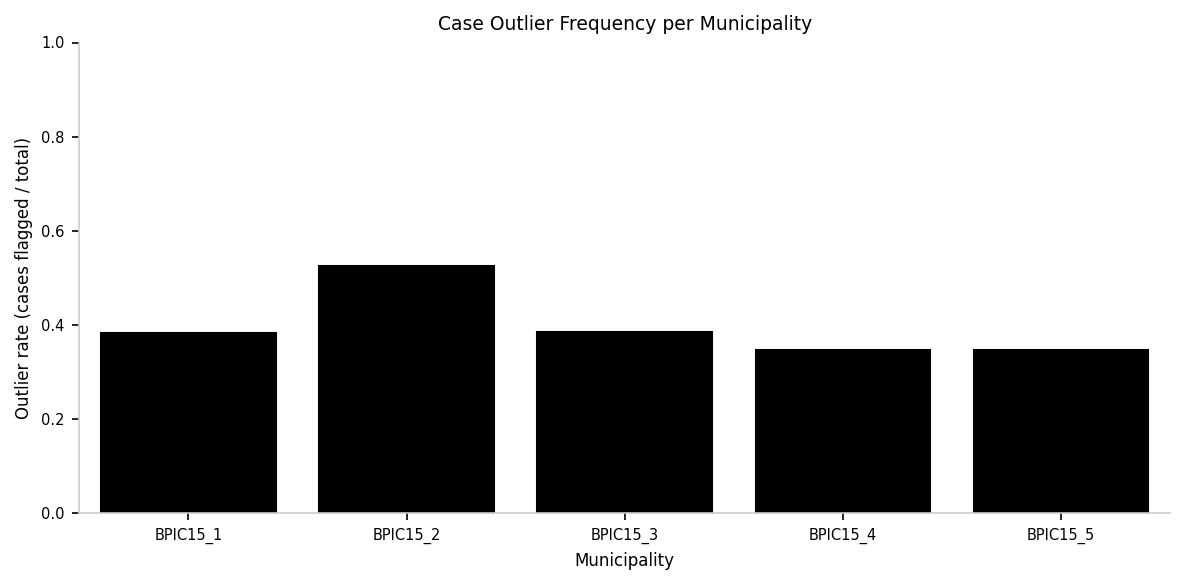

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_stats = (
    cases.groupby("municipality")["case_outlier"]
         .agg(outlier_count="sum", n_cases="count")
         .reset_index()
)
outlier_stats["outlier_rate"] = outlier_stats["outlier_count"] / outlier_stats["n_cases"]

display(outlier_stats)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=outlier_stats,
    x="municipality",
    y="outlier_rate",
    color="black",
    edgecolor="black"
)
plt.ylabel("Outlier rate (cases flagged / total)")
plt.xlabel("Municipality")
plt.title("Case Outlier Frequency per Municipality")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

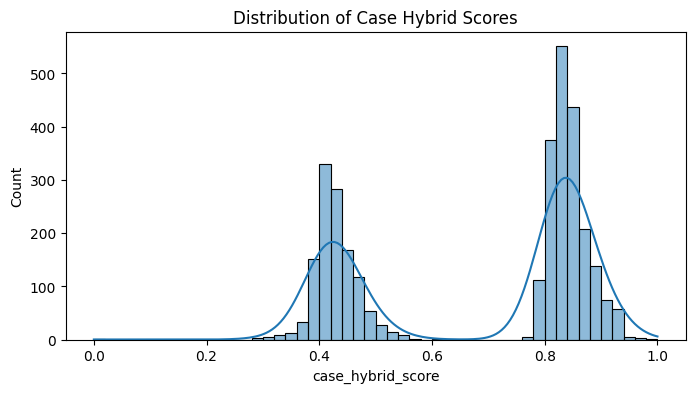

Summary stats (case_hybrid_score):


count    3183.000
mean        0.684
std         0.205
min         0.000
25%         0.436
50%         0.816
75%         0.845
max         1.000
Name: case_hybrid_score, dtype: float64

Top 10 cases by hybrid score:


,case_id,municipality,case_hybrid_score,case_hybrid_raw
1882,5565409,BPIC15_4,1.000,0.985029
1400,4568005,BPIC15_1,0.971,0.957922
166,11070999,BPIC15_5,0.963,0.949538
1899,5597050,BPIC15_4,0.962,0.948583
2688,7762378,BPIC15_3,0.959,0.946281
881,3439262,BPIC15_1,0.950,0.937733
1573,4972924,BPIC15_1,0.949,0.936842
2491,7126056,BPIC15_5,0.942,0.929582
786,3136211,BPIC15_1,0.941,0.929344
888,3451526,BPIC15_1,0.940,0.927933


Bottom 10 cases by hybrid score:


,case_id,municipality,case_hybrid_score,case_hybrid_raw
3182,Unknown,BPIC15_4,0.000,0.036338
1942,5726449,BPIC15_3,0.285,0.306289
1089,3892505,BPIC15_5,0.295,0.316346
1272,4285256,BPIC15_4,0.299,0.320207
1349,4459915,BPIC15_4,0.303,0.324259
1300,4329588,BPIC15_4,0.304,0.324617
971,3617709,BPIC15_5,0.307,0.327661
860,3388796,BPIC15_1,0.313,0.333493
456,19964659,BPIC15_2,0.320,0.339941
2262,6475754,BPIC15_5,0.329,0.348899


In [10]:
# ===============================================
# Code Block 9 — Diagnostics: distributions & spot checks
# ===============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(out['case_hybrid_score'], bins=50, kde=True)
plt.title("Distribution of Case Hybrid Scores")
plt.xlabel("case_hybrid_score")
plt.show()

print("Summary stats (case_hybrid_score):")
display(out['case_hybrid_score'].describe().round(3))

# Show top / bottom cases for inspection
print("Top 10 cases by hybrid score:")
display(out.sort_values('case_hybrid_score', ascending=False).head(10))

print("Bottom 10 cases by hybrid score:")
display(out.sort_values('case_hybrid_score', ascending=True).head(10))


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def set_dashboard_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.dpi": 150,
        "axes.edgecolor": "#cccccc",
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    })

def plot_metric_dashboard(df, metric_cols, titles=None, n_cols=4,
                          suptitle=None, x_axis_label="Index (sorted by metric)"):
    set_dashboard_style()

    n_metrics = len(metric_cols)
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(metric_cols):
        ax = axes[i]
        series = df[col].dropna().sort_values()
        x = np.arange(1, len(series) + 1)

        ax.plot(x, series.values, color="black", linewidth=1.0)
        ax.set_xlim(1, len(series))

        if titles is not None:
            ax.set_title(titles[i])
        else:
            ax.set_title(col.replace("_", " ").title())

        ax.ticklabel_format(axis="y", style="plain", useOffset=False)

        for spine in ["left", "bottom"]:
            ax.spines[spine].set_color("#cccccc")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    for r in range(n_rows):
        for c in range(n_cols):
            idx = r * n_cols + c
            if idx >= n_metrics:
                continue
            ax = axes[idx]
            if r == n_rows - 1:
                ax.set_xlabel(x_axis_label)
            else:
                ax.set_xticklabels([])

    if suptitle is not None:
        fig.suptitle(suptitle, y=1.02, fontsize=11)

    fig.tight_layout()
    return fig, axes

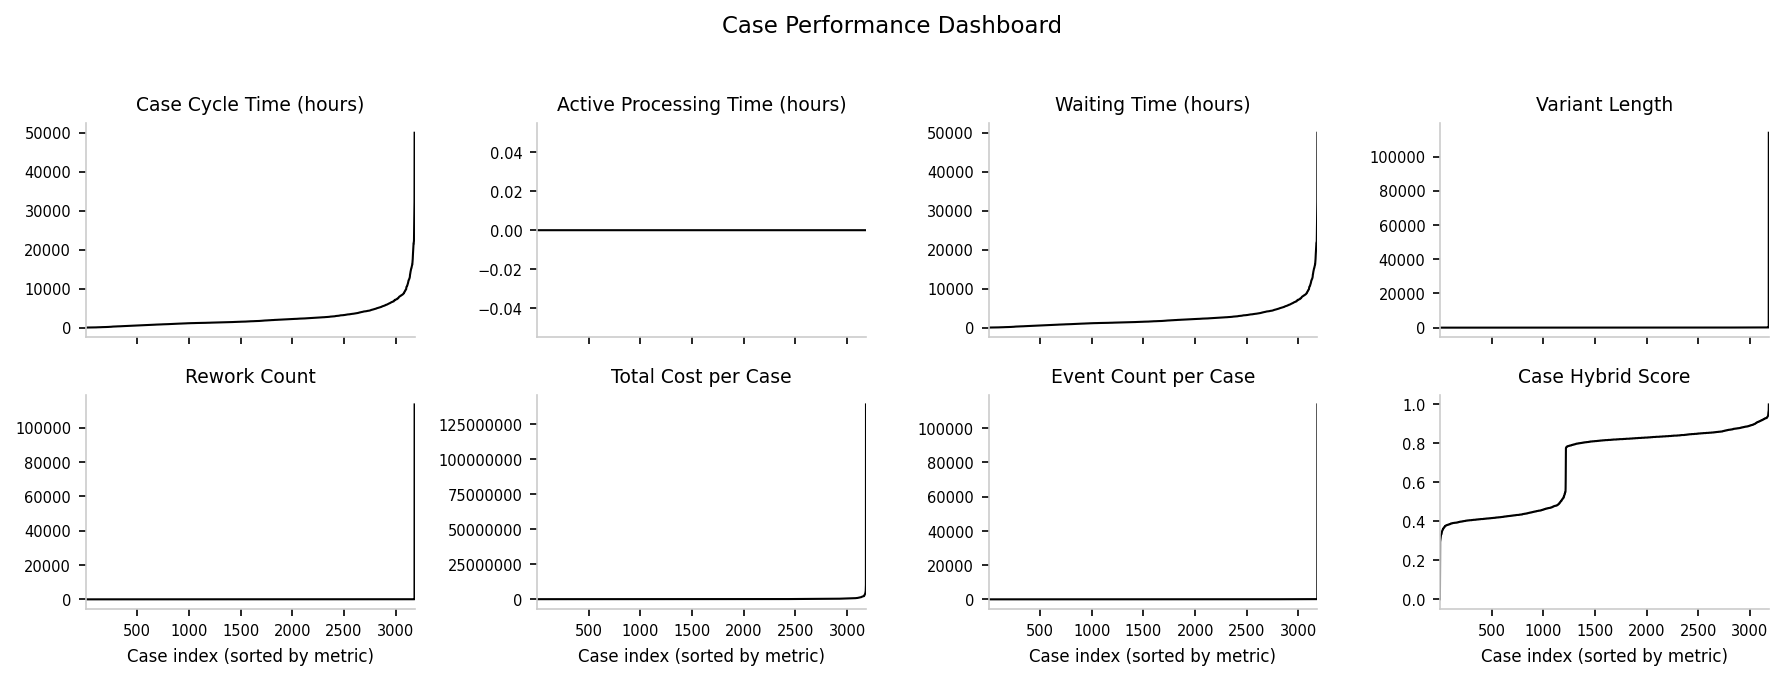

In [12]:
case_dashboard_df = case_df.merge(
    out[["case_id", "case_hybrid_score"]],
    on="case_id",
    how="left"
)

case_metric_cols = [
    "cycle_time_hours",
    "processing_time_hours",
    "wait_time_hours",
    "variant_length",
    "rework_count",
    "total_cost",
    "n_events",
    "case_hybrid_score",
]

case_metric_titles = [
    "Case Cycle Time (hours)",
    "Active Processing Time (hours)",
    "Waiting Time (hours)",
    "Variant Length",
    "Rework Count",
    "Total Cost per Case",
    "Event Count per Case",
    "Case Hybrid Score",
]

fig_case, axes_case = plot_metric_dashboard(
    df=case_dashboard_df,
    metric_cols=case_metric_cols,
    titles=case_metric_titles,
    n_cols=4,
    suptitle="Case Performance Dashboard",
    x_axis_label="Case index (sorted by metric)",
)

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_weight_comparison(weight_data, weight_manual, title, rotation=45):
    """
    Side-by-side bar chart:
    - weight_data:  dict of data-driven weights (PCA+Entropy)
    - weight_manual: dict of standard/manual weights with the same keys
    """
    features = list(weight_data.keys())
    data_vals = [weight_data[f] for f in features]
    manual_vals = [weight_manual[f] for f in features]

    x = np.arange(len(features))
    width = 0.38

    fig, ax = plt.subplots(figsize=(1.6 * len(features), 4))

    # Standard/manual weights
    ax.bar(x - width/2, manual_vals, width,
           label="Standard weights", color="#cccccc", edgecolor="black", linewidth=0.7)
    # Data-driven weights
    ax.bar(x + width/2, data_vals, width,
           label="Data-driven (PCA+Entropy)", color="black", alpha=0.9)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Weight")
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=rotation, ha="right")

    # Minimalist axes, no grid
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax

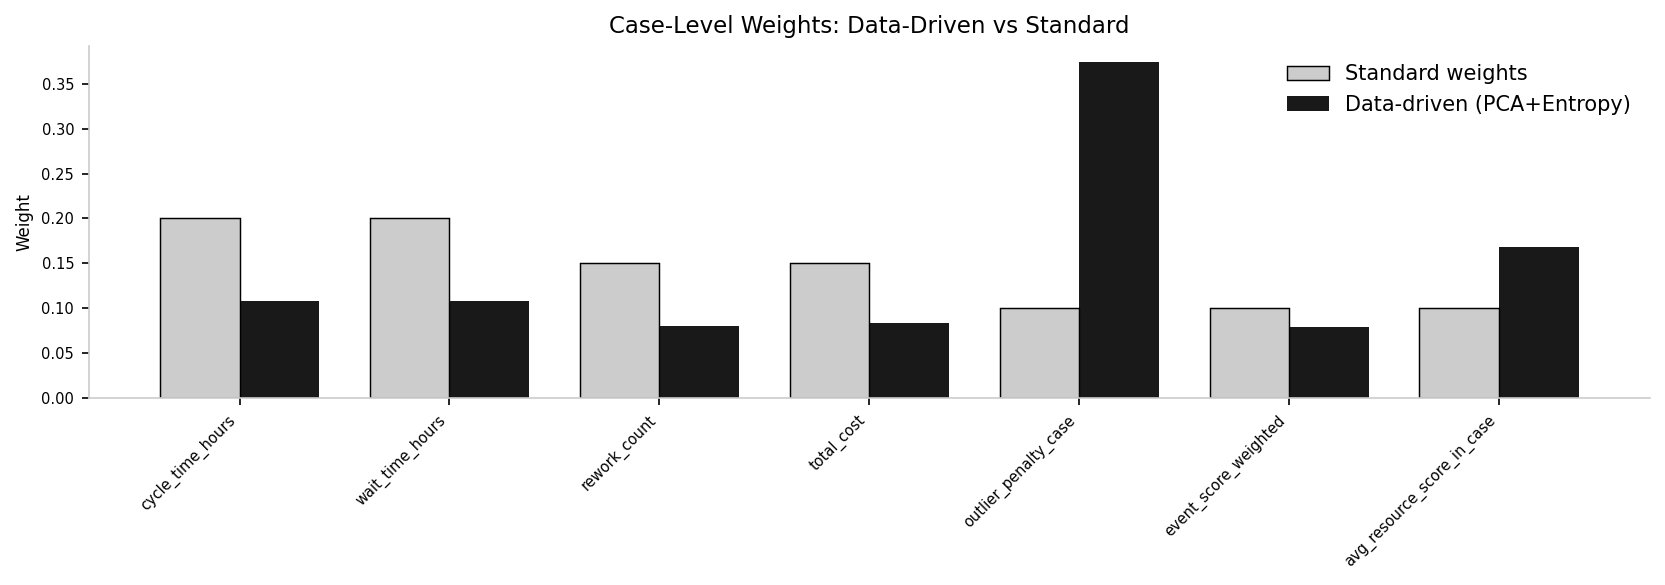

In [14]:
# ----- Standard / manual weights for comparison (edit if needed) -----
case_weights_manual = {
    "cycle_time_hours":          0.20,
    "wait_time_hours":           0.20,
    "rework_count":              0.15,
    "total_cost":                0.15,
    "outlier_penalty_case":      0.10,
    "event_score_weighted":      0.10,
    "avg_resource_score_in_case":0.10,
}

# Normalize manual weights to sum to 1
total_manual = sum(case_weights_manual.values())
case_weights_manual = {k: v / total_manual for k, v in case_weights_manual.items()}

# Ensure order and keys match the learned case_weights
case_weights_ordered = {k: case_weights[k] for k in case_weights_manual.keys()}

fig_case_w, ax_case_w = plot_weight_comparison(
    weight_data=case_weights_ordered,
    weight_manual=case_weights_manual,
    title="Case-Level Weights: Data-Driven vs Standard"
)

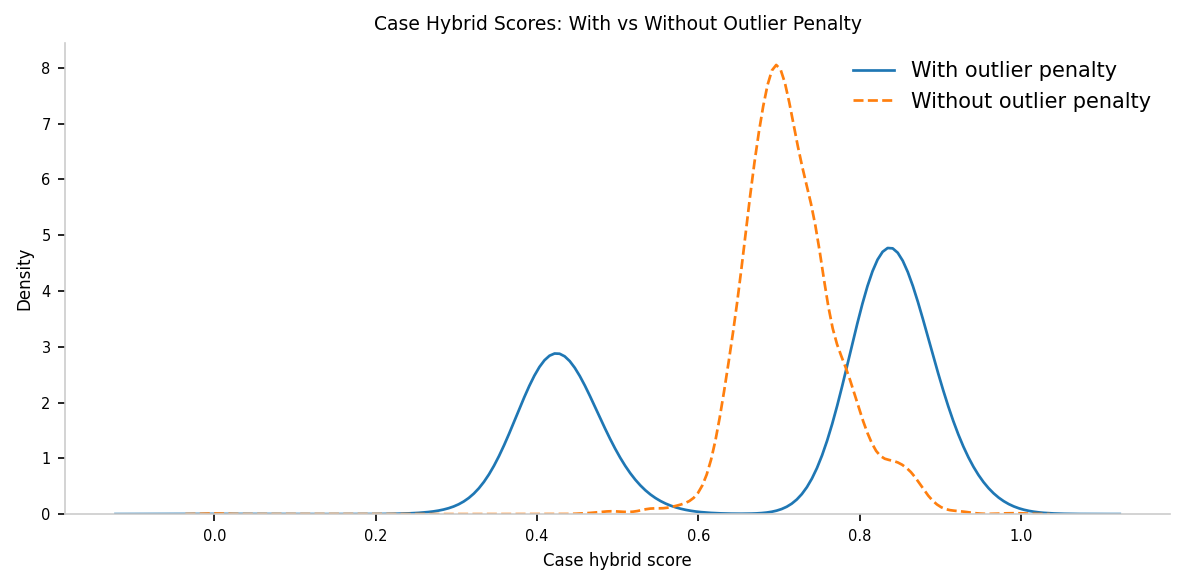

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def recompute_score_without_penalty(norm_df, weights, penalty_col):
    """Recompute hybrid score with the penalty column weight set to zero."""
    w = weights.copy()
    if penalty_col in w:
        w[penalty_col] = 0.0
        total = sum(w.values())
        w = {k: v / total for k, v in w.items()}

    raw = np.zeros(len(norm_df))
    for col in norm_df.columns:
        raw += norm_df[col].values * w[col]
    score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
    return score

# With penalty: already in cases_indexed
score_with_penalty = cases_indexed["case_hybrid_score"].values

# Without penalty: zero out outlier_penalty_case
score_no_penalty = recompute_score_without_penalty(
    case_norm, case_weights, "outlier_penalty_case"
)

plt.figure(figsize=(8, 4))
sns.kdeplot(score_with_penalty, label="With outlier penalty", linewidth=1.3)
sns.kdeplot(score_no_penalty, label="Without outlier penalty", linewidth=1.3, linestyle="--")

plt.xlabel("Case hybrid score")
plt.ylabel("Density")
plt.title("Case Hybrid Scores: With vs Without Outlier Penalty")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [18]:
# Merge original case features (with variant) and hybrid scores
case_with_scores = case_df.merge(
    out[["case_id", "case_hybrid_score"]],
    on="case_id",
    how="left"
)

# Top 5 most frequent activity sequences (variants)
top_variants = (
    case_with_scores["variant"]
    .value_counts()
    .head(5)
    .rename("count")
)

print("Top 5 variants by frequency:")
display(top_variants.to_frame())

# For these variants, show average hybrid performance
variant_perf = (
    case_with_scores[case_with_scores["variant"].isin(top_variants.index)]
    .groupby("variant")
    .agg(
        count=("case_id", "count"),
        avg_hybrid_score=("case_hybrid_score", "mean"),
    )
    .sort_values("count", ascending=False)
)

print("Top 5 variants with average hybrid score:")
display(variant_perf)

Top 5 variants by frequency:


,count
variant,
register submission date request->enter senddate acknowledgement->phase application received->reception through OLO->send confirmation receipt,12
register submission date request->OLO messaging active->applicant is stakeholder->phase application received->send confirmation receipt->send confirmation receipt->enter senddate acknowledgement,11
register submission date request->OLO messaging active->send confirmation receipt->phase application received->send confirmation receipt->enter senddate acknowledgement,8
register submission date request->phase application received->reception through OLO,5
register submission date request->enter senddate acknowledgement->phase application received->reception through OLO->send confirmation receipt->forward to the competent authority->regular procedure without MER,4


Top 5 variants with average hybrid score:


,count,avg_hybrid_score
variant,,
register submission date request->enter senddate acknowledgement->phase application received->reception through OLO->send confirmation receipt,12,0.466333
register submission date request->OLO messaging active->applicant is stakeholder->phase application received->send confirmation receipt->send confirmation receipt->enter senddate acknowledgement,11,0.464364
register submission date request->OLO messaging active->send confirmation receipt->phase application received->send confirmation receipt->enter senddate acknowledgement,8,0.485125
register submission date request->phase application received->reception through OLO,5,0.466600
register submission date request->enter senddate acknowledgement->phase application received->reception through OLO->send confirmation receipt->forward to the competent authority->regular procedure without MER,4,0.486750
